## Zone 0 Install Dependencies

In [1]:
!apt-get update
!apt-get install -y ffmpeg
!pip install -U openai-whisper jiwer
!pip install -U tqdm

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,361 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,904 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net

### Verify Installation

In [2]:
import whisper
import torch
import subprocess

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Whisper loaded:", whisper.load_model("base") is not None)

subprocess.run(["ffmpeg", "-version"], capture_output=True)
print("FFmpeg OK")

Torch: 2.9.0+cu128
CUDA available: True


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 152MiB/s]


Whisper loaded: True
FFmpeg OK


### Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import and Configuration

In [4]:
import json
import subprocess
from pathlib import Path
from typing import List, Dict, Tuple
from dataclasses import dataclass, asdict
import whisper
from jiwer import wer as compute_wer


CONFIG = {
    "cha_dir": Path("/content/drive/MyDrive/asr/data/cha"),
    "audio_dir": Path("/content/drive/MyDrive/asr/data/songs"),
    "output_dir": Path("/content/drive/MyDrive/asr/output/whisper_children_dataset"),
    "whisper_model": "base",
    "sample_size": 200,  # None = tous, ou 500 pour tester
    "train_ratio": 0.8,
    "sample_rate": 16000,
    "audio_extensions": [".wav", ".mp3", ".m4a", ".flac"],
    "quality_threshold": 0.9,  # 0.6 (loose) to 0.85 (strict)
    # Whether to compute expensive audio features
    "analyze_audio_features": True,  # Set to False to speed up analysis
    # Analysis output
    "save_quality_visualization": True,
    "save_filtered_segments": True,
}

# CHILDES roles
CHILD_ROLES = {"Target_Child", "Child", "Sibling", "Peer", "Playmate"}
ADULT_ROLES = {"Investigator", "Teacher", "Mother", "Father", "Adult", "Caregiver", "Parent"}



## Zone 1: File Matching (.cha ↔ Audio)


COMPLETE PIPELINE NOTEBOOK
Input: Dataset folders (data/ca + data/songs)
Output: Training dataset for Whisper fine-tuning (children voices only)

Flow:
1. Match .cha ↔ Audio files
2. Extract .cha segments (word-level timestamps)
3. Segment audio files based on timestamps
4. Evaluate Whisper baseline (children only)
5. Calculate WER (children only)
6. Create training dataset (JSONL + metadata)


In [5]:
import re
from pathlib import Path
from dataclasses import dataclass
from typing import List, Union

@dataclass
class WorSegment:
    speaker: str
    text: str
    words: list  # [(word, start, end)]
    file_name: str = ""  # Ajouter le nom du fichier source


def extract_wor_segments(path: Union[Path, str], debug: bool = False) -> List[WorSegment]:
    """
    Extraire segments %wor d'un fichier .cha

    Args:
        path: Chemin vers un fichier .cha OU un dossier contenant des .cha
        debug: Afficher les infos de parsing

    Returns:
        Liste de WorSegment
    """
    path = Path(path)

    if path.is_dir():
        # Si c'est un dossier, traiter tous les .cha
        return _extract_from_directory(path, debug=debug)
    elif path.is_file():
        # Si c'est un fichier, le traiter
        return _extract_from_file(path, debug=debug)
    else:
        raise FileNotFoundError(f"Chemin invalide: {path}")


def _extract_from_directory(cha_dir: Path, debug: bool = False) -> List[WorSegment]:
    """Extraire de tous les fichiers .cha d'un dossier (récursivement)"""

    # Chercher les .cha dans le dossier ET les sous-dossiers
    cha_files = sorted(cha_dir.glob("*.cha")) + sorted(cha_dir.glob("**/*.cha"))
    # Enlever les doublons
    cha_files = sorted(set(cha_files))

    if not cha_files:
        print(f"Aucun fichier .cha trouvé dans {cha_dir}")
        return []

    if debug:
        print(f"Traitement de {len(cha_files)} fichiers .cha\n")

    all_segments = []

    for cha_file in cha_files:
        if debug:
            print(f" {cha_file.name}...", end=" ")

        segments = _extract_from_file(cha_file, debug=False)
        all_segments.extend(segments)

        if debug:
            print(f"({len(segments)} segments)")

    if debug:
        print(f"\n{'=' * 60}")
        print(f"Total: {len(all_segments)} segments de {len(cha_files)} fichiers")
        print(f"{'=' * 60}\n")

    return all_segments


In [6]:

def _extract_from_file(cha_file: Path, debug: bool = False) -> List[WorSegment]:
    """Extraire de un seul fichier .cha"""

    segments = []
    current_speaker = None
    file_name = cha_file.stem

    with cha_file.open(encoding="utf-8") as f:
        for line in f:
            line = line.rstrip()

            # ── tour principal
            if line.startswith("*"):
                current_speaker = line.split(":", 1)[0].replace("*", "").strip()

            # ── word tier
            elif line.startswith("%wor:"):
                if not current_speaker:
                    continue

                # Extraire la partie après "%wor:"
                wor_content = line.split(":", 1)[1].strip()

                # Nettoyer les caractères de contrôle
                wor_content = wor_content.replace('\x15', '')

                # Parser simple : splitter par espaces et apparier word + timestamp
                tokens = wor_content.split()

                words = []
                i = 0
                while i < len(tokens):
                    token = tokens[i]

                    # Vérifier si c'est un timestamp (format XXXXX_XXXXX)
                    if re.match(r"^\d{5,}_\d{5,}$", token):
                        # C'est un timestamp → l'attacher au mot précédent
                        if words:
                            word, _, _ = words[-1]
                            match = re.match(r"(\d+)_(\d+)", token)
                            if match:
                                start, end = int(match.group(1)), int(match.group(2))
                                words[-1] = (word, start, end)
                        i += 1
                        continue

                    # Sinon, c'est un mot
                    words.append((token, None, None))
                    i += 1

                # Filtrer : garder seulement les mots avec timestamps
                words_with_ts = [(w, s, e) for w, s, e in words if s is not None and e is not None]

                if not words_with_ts:
                    continue

                # Nettoyer le texte : enlever les ponctuations isolées
                clean_words = [w for w, _, _ in words_with_ts if w not in ('?', '.', ',', '!', '+...')]

                if clean_words:
                    clean_text = " ".join(clean_words)

                    segments.append(
                        WorSegment(
                            speaker=current_speaker,
                            text=clean_text,
                            words=words_with_ts,
                            file_name=file_name
                        )
                    )

                    if debug and len(segments) <= 3:
                        print(f"\n {current_speaker}")
                        print(f"   Text: {clean_text[:70]}")
                        print(f"   Words: {words_with_ts[:3]}...")

    if debug:
        print(f"\n{'=' * 60}")
        print(f"Total segments ({file_name}): {len(segments)}")
        print(f"{'=' * 60}")

    return segments

In [7]:
def print_statistics(segments: List[WorSegment]):
    """Afficher statistiques détaillées sur les segments"""

    if not segments:
        print(" Aucun segment trouvé")
        return

    print(f"\n{'=' * 60}")
    print("STATISTIQUES")
    print(f"{'=' * 60}")

    # Par speaker
    by_speaker = {}
    by_file = {}

    for seg in segments:
        # Par speaker
        by_speaker.setdefault(seg.speaker, []).append(seg)

        # Par fichier
        by_file.setdefault(seg.file_name, []).append(seg)

    print(f"\nPar speaker ({len(by_speaker)} speakers):")
    for speaker in sorted(by_speaker.keys()):
        segs = by_speaker[speaker]
        total_duration = sum(s.words[-1][2] - s.words[0][1] for s in segs) / 1000
        print(f"   {speaker:20} {len(segs):3d} segments | {total_duration:6.1f}s audio")

    print(f"\nPar fichier ({len(by_file)} fichiers):")
    for file_name in sorted(by_file.keys()):
        segs = by_file[file_name]
        total_duration = sum(s.words[-1][2] - s.words[0][1] for s in segs) / 1000
        print(f"   {file_name:30} {len(segs):3d} segments | {total_duration:6.1f}s audio")

    # Stats globales
    total_duration = sum(s.words[-1][2] - s.words[0][1] for s in segments) / 1000 / 60
    avg_words = sum(len(s.words) for s in segments) / len(segments)

    print(f"\nGlobales:")
    print(f"   Total segments: {len(segments)}")
    print(f"   Total audio: {total_duration:.1f} minutes")
    print(f"   Mots par segment (moyennes): {avg_words:.1f}")
    print(f"{'=' * 60}\n")


if __name__ == "__main__":
    # Exemple 1: Traiter UN fichier
    print("=" * 60)
    print("EXEMPLE 1: UN FICHIER")
    print("=" * 60)
    segments_single = extract_wor_segments(Path("/content/drive/MyDrive/asr/data/cha/1/01-1a.cha"), debug=True)



EXEMPLE 1: UN FICHIER

 KAT
   Text: un escargot Dylan
   Words: [('un', 10438, 10478), ('escargot', 10739, 10919), ('Dylan', 10919, 11419)]...

 KAT
   Text: comment
   Words: [('comment', 35270, 35770)]...

 WIL
   Text: moi fais la fourmi moi
   Words: [('moi', 38747, 39670), ('fais', 40011, 40612), ('la', 41896, 42136)]...

Total segments (01-1a): 26


In [8]:
def find_matching_files(cha_dir: Path, audio_dir: Path, extensions: List[str]) -> Dict:
    """Match .cha with audio files by relative path (respects subdirectories)"""

    cha_files = sorted(cha_dir.glob("**/*.cha"))
    audio_files = []
    for ext in extensions:
        audio_files.extend(audio_dir.glob(f"**/*{ext}"))

    # Créer dicts: relative_path_with_stem → fichier
    # Exemple: "1/01-1a" pour data/cha/1/01-1a.cha
    cha_by_path = {}
    for f in cha_files:
        relative_stem = str(f.relative_to(cha_dir).with_suffix(""))  # "1/01-1a"
        cha_by_path[relative_stem] = f

    audio_by_path = {}
    for f in audio_files:
        relative_stem = str(f.relative_to(audio_dir).with_suffix(""))
        audio_by_path[relative_stem] = f

    # Matcher: chercher les mêmes chemins relatifs
    matched = []
    cha_missing = []
    audio_orphans = []

    for relative_path in cha_by_path:
        if relative_path in audio_by_path:
            matched.append((cha_by_path[relative_path], audio_by_path[relative_path]))
        else:
            cha_missing.append(cha_by_path[relative_path])

    for relative_path in audio_by_path:
        if relative_path not in cha_by_path:
            audio_orphans.append(audio_by_path[relative_path])

    return {
        "matched": matched,
        "cha_missing_audio": cha_missing,
        "audio_orphans": audio_orphans,
        "total_cha": len(cha_files),
        "total_audio": len(audio_files),
        "matched_count": len(matched)
    }


def print_matching_report(result: Dict):
    """Afficher le rapport de matching"""
    print("\n" + "="*70)
    print("STEP 1: FILE MATCHING (by relative path)")
    print("="*70)
    print(f"\n Found:")
    print(f"   Total .cha files:       {result['total_cha']}")
    print(f"   Total audio files:      {result['total_audio']}")
    print(f"   Matched pairs:        {result['matched_count']}")
    print(f"   .cha missing audio:  {len(result['cha_missing_audio'])}")
    print(f"   Audio orphans:       {len(result['audio_orphans'])}")

    if result['cha_missing_audio']:
        print(f"\n   Missing audio for:")
        for cha in result['cha_missing_audio'][:10]:
            print(f"      - {cha.name}")
        if len(result['cha_missing_audio']) > 10:
            print(f"      ... and {len(result['cha_missing_audio']) - 10} more")

    if result['audio_orphans']:
        print(f"\n   Audio without .cha:")
        for audio in result['audio_orphans'][:10]:
            print(f"      - {audio.name}")
        if len(result['audio_orphans']) > 10:
            print(f"      ... and {len(result['audio_orphans']) - 10} more")

    print("\n" + "="*70 + "\n")


In [9]:
  # ZONE 1: Matching
print("\n" + "="*70)
print("ZONE 1: FILE MATCHING")
print("="*70)
match_result = find_matching_files(CONFIG["cha_dir"], CONFIG["audio_dir"], CONFIG["audio_extensions"])
print_matching_report(match_result)

if not match_result["matched"]:
    print("❌ No matched pairs found!")



ZONE 1: FILE MATCHING

STEP 1: FILE MATCHING (by relative path)

 Found:
   Total .cha files:       247
   Total audio files:      245
   Matched pairs:        245
   .cha missing audio:  2
   Audio orphans:       0

   Missing audio for:
      - 03-13c.cha
      - 05-23a.cha




## Zone 2: Segment Extraction (word-level)

In [10]:
def extract_segments_from_matched(matched_pairs: List[Tuple[Path, Path]]) -> List[WorSegment]:
    """Extract .cha segments from matched files only"""

    print("="*70)
    print("STEP 2: EXTRACT .CHA SEGMENTS")
    print("="*70)

    all_segments = []

    for i, (cha_file, audio_file) in enumerate(matched_pairs):
        segments = extract_wor_segments(cha_file, debug=False)
        all_segments.extend(segments)

        if (i + 1) % 50 == 0:
            print(f"  ✓ {i + 1}/{len(matched_pairs)} files")

    print(f"\nExtracted {len(all_segments)} segments with timestamps\n")
    return all_segments

In [11]:
 # ZONE 2: Extract segments from .cha files
print("\n" + "="*70)
print("ZONE 2: EXTRACT SEGMENTS FROM .CHA")
print("="*70)
segments = extract_segments_from_matched(match_result["matched"])




ZONE 2: EXTRACT SEGMENTS FROM .CHA
STEP 2: EXTRACT .CHA SEGMENTS
  ✓ 50/245 files
  ✓ 100/245 files
  ✓ 150/245 files
  ✓ 200/245 files

Extracted 29272 segments with timestamps



## ZONE 4: Audio Segmentation

In [12]:
"""
AUDIO SEGMENTER WITH MAX LIMIT
Permet de limiter le nombre de segments à traiter pour respecter les limites de calcul
"""
import subprocess
from pathlib import Path
from typing import List, Dict, Tuple

class AudioSegmenter:
    """Segment audio files based on timestamps with optional limit"""

    def __init__(self, output_dir: Path, sample_rate: int = 16000):
        self.output_dir = output_dir
        self.sample_rate = sample_rate
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.speaker_dirs = {}

    def _get_speaker_dir(self, speaker: str) -> Path:
        """Get or create speaker directory"""
        if speaker not in self.speaker_dirs:
            d = self.output_dir / speaker
            d.mkdir(exist_ok=True)
            self.speaker_dirs[speaker] = d
        return self.speaker_dirs[speaker]

    def extract_segment(self, audio_file: Path, start_ms: int, end_ms: int, output_path: Path) -> bool:
        """Extract audio segment using ffmpeg"""
        if not audio_file.exists():
            return False

        start_sec = start_ms / 1000.0
        duration_sec = (end_ms - start_ms) / 1000.0

        cmd = [
            "ffmpeg", "-i", str(audio_file),
            "-ss", str(start_sec), "-t", str(duration_sec),
            "-acodec", "pcm_s16le", "-ar", str(self.sample_rate), "-ac", "1",
            "-y", str(output_path)
        ]

        try:
            subprocess.run(cmd, check=True, capture_output=True, timeout=10)
            return True
        except:
            return False

    def segment_all(self, segments: List[WorSegment], matched_pairs: List[Tuple[Path, Path]],
                   max_segments: int = None) -> Dict:
        """
        Segment audio files with optional limit

        Args:
            segments: List of WorSegment objects
            matched_pairs: List of (cha_file, audio_file) tuples
            max_segments: Maximum number of segments to process (None = all)

        Returns:
            Dict with:
            - extracted: List of successfully extracted segments
            - skipped: Number of skipped segments (no audio file)
            - stopped_at: Number processed before stopping (if max reached)
            - limited: Boolean, whether max_segments was reached
        """

        print("="*70)
        print(" STEP 3: SEGMENT AUDIO FILES")
        print("="*70)

        audio_lookup = {audio.stem: audio for _, audio in matched_pairs}

        # Déterminer le nombre de segments à traiter
        segments_to_process = segments
        limited = False

        if max_segments is not None:
            if len(segments) > max_segments:
                segments_to_process = segments[:max_segments]
                limited = True
                print(f"\n LIMIT SET: Processing {max_segments}/{len(segments)} segments")
            else:
                print(f"\n Processing all {len(segments)} segments (limit: {max_segments})")
        else:
            print(f"\n Processing all {len(segments)} segments (no limit)")

        results = []
        skipped = 0

        for i, seg in enumerate(segments_to_process):
            audio_file = audio_lookup.get(seg.file_name)
            if not audio_file or not audio_file.exists():
                skipped += 1
                continue

            segment_id = f"{seg.file_name}_{seg.speaker}_{i:05d}"
            speaker_dir = self._get_speaker_dir(seg.speaker)
            output_path = speaker_dir / f"{segment_id}.wav"

            start_ms = seg.words[0][1]
            end_ms = seg.words[-1][2]

            if self.extract_segment(audio_file, start_ms, end_ms, output_path):
                results.append({
                    "segment_id": segment_id,
                    "speaker": seg.speaker,
                    "file_name": seg.file_name,
                    "audio_path": str(output_path),
                    "duration_ms": end_ms - start_ms,
                    "text": seg.text,
                    "num_words": len(seg.words)
                })

            if (i + 1) % 200 == 0:
                print(f"  ✓ {i + 1}/{len(segments_to_process)} segments")

        print(f"\n Segmented {len(results)} audio files")
        if skipped > 0:
            print(f"   Skipped (no audio): {skipped}")

        if limited:
            print(f"   STOPPED AT LIMIT: {len(segments_to_process)} processed")
            print(f"   Remaining: {len(segments) - len(segments_to_process)} segments not processed")

        print()

        return {
            "extracted": results,
            "skipped": skipped,
            "stopped_at": len(segments_to_process),
            "limited": limited,
            "total_segments": len(segments)
        }

# ============================================================================
# HELPER: Resume segmentation
# ============================================================================

def resume_segmentation(segments: List[WorSegment], matched_pairs: List[Tuple[Path, Path]],
                       output_dir: Path, start_from: int = 0, max_segments: int = None) -> Dict:
    """
    Resume segmentation from a specific point

    Utile si tu veux reprendre après avoir atteint ta limite

    Args:
        segments: List of all WorSegment objects
        matched_pairs: List of (cha_file, audio_file) tuples
        output_dir: Output directory
        start_from: Index to start from (0 = beginning)
        max_segments: Maximum segments to process from start_from

    Returns:
        Dict with results
    """

    print("="*70)
    print("RESUME SEGMENTATION")
    print("="*70)
    print(f"\n  Resuming from segment {start_from}")
    print(f"  Total remaining: {len(segments) - start_from}\n")

    # Get remaining segments
    remaining_segments = segments[start_from:]

    segmenter = AudioSegmenter(output_dir)
    results = segmenter.segment_all(remaining_segments, matched_pairs, max_segments)

    # Adjust stopped_at to reflect actual position in original list
    results["stopped_at"] = start_from + results["stopped_at"]

    return results

In [20]:
 # ZONE 3: Segment audio files
print("\n" + "="*70)
print("ZONE 3: CREATE AUDIO SEGMENTS")
print("="*70)
segmenter = AudioSegmenter(CONFIG["output_dir"] / "audio_segments")
segment_all_result = segmenter.segment_all(segments, match_result["matched"], max_segments=800)
audio_segments = segment_all_result["extracted"]




ZONE 3: CREATE AUDIO SEGMENTS
 STEP 3: SEGMENT AUDIO FILES

 LIMIT SET: Processing 800/29272 segments
  ✓ 200/800 segments
  ✓ 400/800 segments
  ✓ 600/800 segments
  ✓ 800/800 segments

 Segmented 800 audio files
   STOPPED AT LIMIT: 800 processed
   Remaining: 28472 segments not processed



## ZONE 5: Extract Speaker Metadata

In [21]:
def extract_all_speakers_info(matched_pairs: List[Tuple[Path, Path]]) -> Dict[str, str]:
    """Extract speaker roles from all .cha files"""

    all_speakers = {}

    for cha_file, _ in matched_pairs:
        with cha_file.open(encoding="utf-8") as f:
            for line in f:
                if line.startswith("@Participants:"):
                    participants_str = line.split(":", 1)[1].strip()
                    for participant in participants_str.split(","):
                        participant = participant.strip()
                        parts = participant.rsplit(" ", 1)
                        if len(parts) == 2:
                            speaker_name, role = parts
                            all_speakers[speaker_name] = role

    return all_speakers

In [15]:
  # ZONE 4: Get speaker info
print("\n" + "="*70)
print("ZONE 4: EXTRACT SPEAKER ROLES")
print("="*70)
speakers_info = extract_all_speakers_info(match_result["matched"])


ZONE 4: EXTRACT SPEAKER ROLES


## Zone 4 (bis): Conversion en AudioSegmentMeta

Convertit les dicts produits par Zone 3 (`segment_all`) en objets `AudioSegmentMeta` compatibles avec la Zone 6 (merge contrôlé).

In [22]:
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Optional


@dataclass
class AudioSegmentMeta:
    """
    Représente un segment audio issu de Zone 3, enrichi pour la Zone 6.
    Compatible avec merge_segments_to_target_duration().
    """
    segment_id: str
    speaker: str
    file_name: str               # Nom du fichier source (.cha / audio)
    audio_file: Path             # Chemin du fichier audio SOURCE (pas le segment coupé)
    mfa_start_ms: float          # Début dans le fichier source
    mfa_end_ms: float            # Fin dans le fichier source
    text: str
    word_times: List[Dict]       # [{'word': str, 'start_ms': float, 'end_ms': float}]
    segment_audio_path: Optional[Path] = None  # Chemin du segment déjà découpé (Zone 3)

    @property
    def mfa_duration_ms(self) -> float:
        return self.mfa_end_ms - self.mfa_start_ms

    @property
    def duration_sec(self) -> float:
        return self.mfa_duration_ms / 1000.0


def convert_audio_segments_to_meta(
    audio_segments_dicts: List[Dict],
    segments_wor: List,          # Liste des WorSegment originaux (même ordre)
    matched_pairs: List
) -> List[AudioSegmentMeta]:
    """
    Convertit les dicts retournés par AudioSegmenter.segment_all() en
    objets AudioSegmentMeta, en réinjectant les timestamps word-level
    depuis les WorSegment originaux.

    Args:
        audio_segments_dicts: Résultat de segment_all_result['extracted']
        segments_wor: Liste complète des WorSegment (Zone 2)
        matched_pairs: Liste des (cha_file, audio_file)

    Returns:
        List[AudioSegmentMeta]
    """
    print('=' * 70)
    print('ZONE 4 BIS: CONVERT TO AudioSegmentMeta')
    print('=' * 70)

    # Build lookup: audio by file_name
    audio_lookup = {audio.stem: audio for _, audio in matched_pairs}

    # Build lookup: WorSegment by segment_id
    # Segment IDs sont construits comme: {file_name}_{speaker}_{i:05d}
    wor_by_id: Dict[str, object] = {}
    for i, seg in enumerate(segments_wor):
        seg_id = f'{seg.file_name}_{seg.speaker}_{i:05d}'
        wor_by_id[seg_id] = seg

    meta_segments: List[AudioSegmentMeta] = []
    warnings = 0

    for d in audio_segments_dicts:
        seg_id = d['segment_id']
        wor = wor_by_id.get(seg_id)

        if wor is None:
            warnings += 1
            continue

        # Extraire les timestamps word-level
        word_times = [
            {'word': w, 'start_ms': float(s), 'end_ms': float(e)}
            for w, s, e in wor.words
            if s is not None and e is not None
        ]

        if not word_times:
            warnings += 1
            continue

        audio_file = audio_lookup.get(d['file_name'])

        meta = AudioSegmentMeta(
            segment_id=seg_id,
            speaker=d['speaker'],
            file_name=d['file_name'],
            audio_file=audio_file,
            mfa_start_ms=float(word_times[0]['start_ms']),
            mfa_end_ms=float(word_times[-1]['end_ms']),
            text=d['text'],
            word_times=word_times,
            segment_audio_path=Path(d['audio_path'])
        )
        meta_segments.append(meta)

    print(f'  ✅ Converted: {len(meta_segments)} segments')
    if warnings > 0:
        print(f'  ⚠️  Skipped (no matching WorSegment): {warnings}')

    # Stats
    from collections import Counter
    by_speaker = Counter(m.speaker for m in meta_segments)
    print(f'  📊 By speaker: {dict(by_speaker)}')
    if meta_segments:
        durations = [m.duration_sec for m in meta_segments]
        import numpy as np
        print(f'  📊 Avg duration: {np.mean(durations):.2f}s  |  '
              f'Min: {np.min(durations):.2f}s  |  Max: {np.max(durations):.2f}s')
        short = sum(1 for d in durations if d < 10)
        ok    = sum(1 for d in durations if 10 <= d <= 30)
        long_ = sum(1 for d in durations if d > 30)
        print(f'  📊 <10s: {short}  |  10-30s: {ok}  |  >30s: {long_}')
    print()
    return meta_segments


# ── Exécution ──────────────────────────────────────────────────────────────
audio_segment_metas = convert_audio_segments_to_meta(
    audio_segments_dicts=audio_segments,   # list of dicts from Zone 3
    segments_wor=segments,                 # WorSegment list from Zone 2
    matched_pairs=match_result['matched']
)


ZONE 4 BIS: CONVERT TO AudioSegmentMeta
  ✅ Converted: 800 segments
  📊 By speaker: {'KAT': 511, 'WIL': 49, 'ELI': 11, 'UNI': 9, 'RIT': 9, 'SOF': 17, 'MAT': 28, 'CHI': 2, 'KLO': 45, 'CAR': 2, 'LUS': 34, 'MAI': 37, 'DYL': 15, 'MAS': 10, 'SAR': 13, 'LAN': 4, 'ELE': 4}
  📊 Avg duration: 2.96s  |  Min: 0.50s  |  Max: 145.82s
  📊 <10s: 780  |  10-30s: 13  |  >30s: 7



## Zone 6 : Merge contrôlé par speaker (10–30 sec)

Fusionne les segments consécutifs **du même speaker** pour atteindre 10–30 secondes.  
Produit :
- Des **fichiers audio fusionnés** (via `ffmpeg concat`)
- Des **fichiers `.cha` fusionnés** correspondants

> ⚠️  Le merge ne traverse **jamais** une frontière de speaker ni de fichier source.

In [23]:
import subprocess
import tempfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np


# ─────────────────────────────────────────────────────────────────────────────
# Dataclass résultat
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class MergedSegment:
    """
    Résultat d'un merge contrôlé par speaker — audio silence-padded.

    L'audio produit contient uniquement les tours de parole du speaker cible.
    Les intervalles occupés par d'autres speakers sont remplacés par du silence.

    Les timestamps word-level dans word_times_merged sont en ms RELATIFS
    au début du fichier audio produit (0 ms = début du fichier).
    """
    merge_id: str
    speaker: str
    file_name: str
    original_segment_ids: List[str]

    texts: List[str]
    merged_text: str

    # Durée totale du fichier audio produit (speech + silences inter-segments)
    merged_duration_ms: float

    # Timestamps word-level RELATIFS au début de l'audio produit
    word_times_merged: List[Dict]  # [{'word': str, 'start_ms': float, 'end_ms': float}]

    # Segments sources utilisés
    source_segments: List  # List[AudioSegmentMeta]

    audio_source_file: Path
    merged_audio_path: Optional[Path] = None
    merged_cha_path: Optional[Path] = None

    @property
    def duration_sec(self) -> float:
        return self.merged_duration_ms / 1000.0

    @property
    def num_words(self) -> int:
        return len(self.word_times_merged)

    def to_dict(self) -> Dict:
        return {
            'merge_id': self.merge_id,
            'speaker': self.speaker,
            'file_name': self.file_name,
            'merged_text': self.merged_text,
            'duration_sec': self.duration_sec,
            'num_words': self.num_words,
            'num_segments': len(self.original_segment_ids),
            'word_times': self.word_times_merged,
            'merged_audio_path': str(self.merged_audio_path),
            'merged_cha_path': str(self.merged_cha_path),
        }


# ─────────────────────────────────────────────────────────────────────────────
# Helpers : extraction, silence, concat
# ─────────────────────────────────────────────────────────────────────────────

def _extract_segment_to_temp(
    source_file: Path,
    start_ms: float,
    end_ms: float,
    tmp_dir: str,
    idx: int,
    sample_rate: int = 16000
) -> Optional[Path]:
    """
    Extrait un segment du fichier audio source vers un WAV temporaire.
    Retourne le chemin du fichier temp, ou None si échec.
    """
    out = Path(tmp_dir) / f'seg_{idx:04d}.wav'
    cmd = [
        'ffmpeg', '-i', str(source_file),
        '-ss', str(start_ms / 1000.0),
        '-t', str((end_ms - start_ms) / 1000.0),
        '-acodec', 'pcm_s16le', '-ar', str(sample_rate), '-ac', '1',
        '-y', str(out)
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True, timeout=30)
        return out
    except Exception as e:
        print(f'    ffmpeg extract error (seg {idx}): {e}')
        return None


def _generate_silence(
    duration_ms: float,
    tmp_dir: str,
    idx: int,
    sample_rate: int = 16000
) -> Optional[Path]:
    """
    Génère un fichier WAV de silence de durée duration_ms.
    """
    out = Path(tmp_dir) / f'sil_{idx:04d}.wav'
    cmd = [
        'ffmpeg',
        '-f', 'lavfi',
        '-i', f'anullsrc=r={sample_rate}:cl=mono',
        '-t', str(duration_ms / 1000.0),
        '-acodec', 'pcm_s16le', '-ar', str(sample_rate), '-ac', '1',
        '-y', str(out)
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True, timeout=10)
        return out
    except Exception as e:
        print(f'    ffmpeg silence error: {e}')
        return None


def _concat_wav_files(
    wav_files: List[Path],
    output_path: Path,
    sample_rate: int = 16000
) -> bool:
    """
    Concatène une liste de fichiers WAV via le filtre concat ffmpeg.
    """
    if not wav_files:
        return False

    if len(wav_files) == 1:
        import shutil
        shutil.copy(wav_files[0], output_path)
        return True

    inputs = []
    for f in wav_files:
        inputs += ['-i', str(f)]

    filter_str = ''.join(f'[{i}:0]' for i in range(len(wav_files)))
    filter_str += f'concat=n={len(wav_files)}:v=0:a=1[out]'

    cmd = (
        ['ffmpeg'] + inputs +
        ['-filter_complex', filter_str,
         '-map', '[out]',
         '-acodec', 'pcm_s16le', '-ar', str(sample_rate), '-ac', '1',
         '-y', str(output_path)]
    )
    try:
        subprocess.run(cmd, check=True, capture_output=True, timeout=60)
        return True
    except Exception as e:
        print(f'    ffmpeg concat error: {e}')
        return False


def _compute_relative_word_times(source_segments: List) -> Tuple[List[Dict], float]:
    """
    Recalcule les timestamps word-level relatifs au début du fichier audio produit.

    Stratégie :
      - Chaque segment occupe sa durée exacte dans le fichier produit.
      - Le silence entre deux segments est préservé (= gap entre mfa_end du précédent
        et mfa_start du suivant dans le fichier source).
      - cursor_ms suit la position courante dans le fichier produit.

    Retourne:
        (word_times_relative, total_duration_ms)
    """
    cursor_ms = 0.0
    word_times_rel = []

    for k, seg in enumerate(source_segments):
        # offset = décalage entre position courante dans le produit et position dans la source
        offset_ms = cursor_ms - seg.mfa_start_ms

        for wt in seg.word_times:
            word_times_rel.append({
                'word': wt['word'],
                'start_ms': round(wt['start_ms'] + offset_ms, 1),
                'end_ms':   round(wt['end_ms']   + offset_ms, 1),
            })

        cursor_ms += seg.mfa_duration_ms  # avancer d'autant que la durée speech

        # Ajouter le silence inter-segments
        if k < len(source_segments) - 1:
            gap_ms = max(0.0, source_segments[k + 1].mfa_start_ms - seg.mfa_end_ms)
            cursor_ms += gap_ms

    return word_times_rel, cursor_ms


def _build_silence_padded_audio(
    source_segments: List,
    output_path: Path,
    sample_rate: int = 16000
) -> Tuple[bool, List[Dict], float]:
    """
    Construit un WAV silence-padded :
      - Extrait chaque segment individuellement (voix du speaker uniquement)
      - Insère du silence aux intervalles inter-segments
      - Concatène le tout

    Retourne:
        (success, word_times_relative, total_duration_ms)
    """
    import tempfile as _tempfile

    word_times_rel, total_dur_ms = _compute_relative_word_times(source_segments)

    with _tempfile.TemporaryDirectory() as tmp_dir:
        wav_parts: List[Path] = []

        for k, seg in enumerate(source_segments):
            # Segment speech
            seg_wav = _extract_segment_to_temp(
                source_file=seg.audio_file,
                start_ms=seg.mfa_start_ms,
                end_ms=seg.mfa_end_ms,
                tmp_dir=tmp_dir,
                idx=k * 2,
                sample_rate=sample_rate
            )
            if seg_wav is None:
                return False, [], 0.0
            wav_parts.append(seg_wav)

            # Silence inter-segments
            if k < len(source_segments) - 1:
                gap_ms = max(0.0, source_segments[k + 1].mfa_start_ms - seg.mfa_end_ms)
                if gap_ms > 1:  # ignorer les gaps < 1 ms
                    sil_wav = _generate_silence(
                        duration_ms=gap_ms,
                        tmp_dir=tmp_dir,
                        idx=k * 2 + 1,
                        sample_rate=sample_rate
                    )
                    if sil_wav:
                        wav_parts.append(sil_wav)

        ok = _concat_wav_files(wav_parts, output_path, sample_rate)
        return ok, word_times_rel, total_dur_ms


# ─────────────────────────────────────────────────────────────────────────────
# Génération .cha
# ─────────────────────────────────────────────────────────────────────────────

def _generate_cha(merged: 'MergedSegment', output_path: Path) -> None:
    """
    Génère un fichier .cha CHAT pour le segment fusionné.
    Les timestamps bullet et %wor sont en ms RELATIFS au début du fichier audio produit.
    """
    lines = [
        '@Begin',
        '@Languages:\tfra',
        f'@Participants:\t{merged.speaker} {merged.speaker} Speaker',
        f'@ID:\tfra|corpus|{merged.speaker}|||Speaker|||',
        f'@Media:\t{merged.merge_id}, audio',
        '',
        # Tour principal : bullet couvre toute la durée du fichier produit
        f'*{merged.speaker}:\t{merged.merged_text} \x150_{int(merged.merged_duration_ms)}\x15',
    ]

    # Tier %wor
    wor_tokens = [
        f"{wt['word']} {int(wt['start_ms'])}_{int(wt['end_ms'])}"
        for wt in merged.word_times_merged
    ]
    lines.append('%wor:\t' + ' '.join(wor_tokens))
    lines += ['', '@End']

    output_path.write_text('\n'.join(lines), encoding='utf-8')


# ─────────────────────────────────────────────────────────────────────────────
# Algorithme de merge greedy par speaker
# ─────────────────────────────────────────────────────────────────────────────

def merge_segments_by_speaker(
    audio_segment_metas: List,
    output_dir: Path,
    target_duration_sec: Tuple[float, float] = (10.0, 30.0),
    sample_rate: int = 16000,
    generate_audio: bool = True,
    generate_cha: bool = True,
    verbose: bool = True
) -> List[MergedSegment]:
    """
    Merge contrôlé par speaker avec silence-padding.

    Règles :
    - Fusionne uniquement des segments consécutifs du MEME speaker / MEME fichier source.
    - Stratégie greedy : accumule jusqu'a atteindre min_duration (speech only),
      flush des que c'est atteint.
    - Si le prochain segment ferait depasser max_duration (speech) ET qu'on est deja
      >= min, on flush avant.
    - Groupes residuels < min_duration : logges et skipped.

    Audio produit :
    - Silence aux intervalles occupes par d'autres speakers : voix cible uniquement.
    - Duree totale = somme(speech) + somme(gaps inter-segments du meme speaker).

    Timestamps .cha :
    - Relatifs au debut du fichier audio produit (0 ms = debut du fichier).
    """

    min_ms = target_duration_sec[0] * 1000
    max_ms = target_duration_sec[1] * 1000

    output_dir = Path(output_dir)
    audio_out = output_dir / 'audio'
    cha_out   = output_dir / 'cha'
    audio_out.mkdir(parents=True, exist_ok=True)
    cha_out.mkdir(parents=True, exist_ok=True)

    # ── Grouper consecutivement par (file_name, speaker) ─────────────────
    groups = []
    i = 0
    while i < len(audio_segment_metas):
        cur = audio_segment_metas[i]
        key = (cur.file_name, cur.speaker)
        grp = [cur]
        j = i + 1
        while j < len(audio_segment_metas):
            if (audio_segment_metas[j].file_name,
                    audio_segment_metas[j].speaker) == key:
                grp.append(audio_segment_metas[j])
                j += 1
            else:
                break
        groups.append((cur.file_name, cur.speaker, grp))
        i = j

    merged_segments: List[MergedSegment] = []
    merge_counter = 0
    skipped_short = 0

    def _flush(buf: List, ctr: int) -> Tuple[Optional[MergedSegment], int]:
        nonlocal skipped_short
        if not buf:
            return None, ctr

        speech_ms = sum(s.mfa_duration_ms for s in buf)
        if speech_ms < min_ms:
            skipped_short += 1
            if verbose:
                ids = ' | '.join(s.segment_id for s in buf)
                print(f'    WARNING: speech too short ({speech_ms/1000:.2f}s < '
                      f'{min_ms/1000:.0f}s), skipping: {ids}')
            return None, ctr

        # Duree totale = speech + silences inter-segments
        gaps_ms = sum(
            max(0.0, buf[k+1].mfa_start_ms - buf[k].mfa_end_ms)
            for k in range(len(buf) - 1)
        )
        total_dur_ms = speech_ms + gaps_ms

        merge_id = f'merged_{buf[0].file_name}_{buf[0].speaker}_{ctr:04d}'

        return MergedSegment(
            merge_id=merge_id,
            speaker=buf[0].speaker,
            file_name=buf[0].file_name,
            original_segment_ids=[s.segment_id for s in buf],
            texts=[s.text for s in buf],
            merged_text=' '.join(s.text for s in buf),
            merged_duration_ms=total_dur_ms,
            word_times_merged=[],       # rempli lors de la generation audio
            source_segments=list(buf),
            audio_source_file=buf[0].audio_file
        ), ctr + 1

    for file_name, speaker, group in groups:
        buf: List = []
        buf_speech_ms = 0.0

        for seg in group:
            seg_dur = seg.mfa_duration_ms

            # Flush si on depasse max ET qu'on est deja >= min
            if buf and (buf_speech_ms + seg_dur > max_ms) and (buf_speech_ms >= min_ms):
                merged, merge_counter = _flush(buf, merge_counter)
                if merged:
                    merged_segments.append(merged)
                buf = []
                buf_speech_ms = 0.0

            buf.append(seg)
            buf_speech_ms += seg_dur

            # Flush des qu'on atteint min
            if buf_speech_ms >= min_ms:
                merged, merge_counter = _flush(buf, merge_counter)
                if merged:
                    merged_segments.append(merged)
                buf = []
                buf_speech_ms = 0.0

        # Residus fin de groupe
        if buf:
            merged, merge_counter = _flush(buf, merge_counter)
            if merged:
                merged_segments.append(merged)

    # ── Generer les fichiers ──────────────────────────────────────────────
    if verbose:
        print(f'\n  Building silence-padded audio + .cha for {len(merged_segments)} segments...')

    success_audio = 0
    success_cha   = 0

    for merged in merged_segments:
        spk_audio_dir = (audio_out / merged.speaker)
        spk_cha_dir   = (cha_out   / merged.speaker)
        spk_audio_dir.mkdir(exist_ok=True)
        spk_cha_dir.mkdir(exist_ok=True)

        # Audio silence-padded
        if generate_audio:
            audio_path = spk_audio_dir / f'{merged.merge_id}.wav'
            ok, wt_rel, total_dur = _build_silence_padded_audio(
                source_segments=merged.source_segments,
                output_path=audio_path,
                sample_rate=sample_rate
            )
            if ok:
                merged.merged_audio_path = audio_path
                merged.word_times_merged = wt_rel
                merged.merged_duration_ms = total_dur  # mise a jour avec duree reelle
                success_audio += 1

        # Calculer les timestamps relatifs si audio non genere (generate_audio=False)
        if not merged.word_times_merged:
            wt_rel, total_dur = _compute_relative_word_times(merged.source_segments)
            merged.word_times_merged = wt_rel
            merged.merged_duration_ms = total_dur

        # .cha
        if generate_cha:
            cha_path = spk_cha_dir / f'{merged.merge_id}.cha'
            _generate_cha(merged, cha_path)
            merged.merged_cha_path = cha_path
            success_cha += 1

    # ── Rapport ───────────────────────────────────────────────────────────
    if verbose:
        print('\n' + '=' * 80)
        print('ZONE 6: MERGE REPORT')
        print('=' * 80)
        print(f'  Merged segments created   : {len(merged_segments)}')
        if generate_audio:
            print(f'  Audio files generated     : {success_audio}/{len(merged_segments)}')
            print(f'     Strategy: silence-padded (other speakers masked)')
        if generate_cha:
            print(f'  .cha files generated      : {success_cha}/{len(merged_segments)}')
            print(f'     Timestamps: relative to start of produced audio file')
        if skipped_short > 0:
            print(f'  Groups skipped (<{target_duration_sec[0]:.0f}s speech): {skipped_short}')

        if merged_segments:
            total_durs   = [m.duration_sec for m in merged_segments]
            speech_durs  = [
                sum(s.mfa_duration_ms for s in m.source_segments) / 1000.0
                for m in merged_segments
            ]
            print(f'\n  Duration stats (speech + silence):')
            print(f'     Avg: {np.mean(total_durs):.2f}s  |  '
                  f'Min: {np.min(total_durs):.2f}s  |  Max: {np.max(total_durs):.2f}s')
            print(f'  Duration stats (speech only):')
            print(f'     Avg: {np.mean(speech_durs):.2f}s  |  '
                  f'Min: {np.min(speech_durs):.2f}s  |  Max: {np.max(speech_durs):.2f}s')

            in_range = sum(
                1 for d in speech_durs
                if target_duration_sec[0] <= d <= target_duration_sec[1]
            )
            print(f'\n  In [{target_duration_sec[0]:.0f}s, {target_duration_sec[1]:.0f}s] '
                  f'(speech): {in_range}/{len(merged_segments)} '
                  f'({100*in_range/len(merged_segments):.1f}%)')

            from collections import Counter
            by_spk = Counter(m.speaker for m in merged_segments)
            print(f'\n  By speaker: {dict(by_spk)}')

    return merged_segments


In [24]:
# ── ZONE 6: Exécution ─────────────────────────────────────────────────────
print('\n' + '=' * 80)
print('ZONE 6: MERGE CONTRÔLÉ PAR SPEAKER (10–30 sec)')
print('=' * 80)

merged_output_dir = CONFIG['output_dir'] / 'merged_segments'

merged_segments = merge_segments_by_speaker(
    audio_segment_metas=audio_segment_metas,   # Depuis Zone 4 bis
    output_dir=merged_output_dir,
    target_duration_sec=(10.0, 30.0),
    sample_rate=16000,
    generate_audio=True,
    generate_cha=True,
    verbose=True
)

print('\n' + '=' * 80)
print('✅ ZONE 6 COMPLETE')
print(f'   Output : {merged_output_dir}')
print(f'            ├── audio/<speaker>/<merge_id>.wav')
print(f'            └── cha/<speaker>/<merge_id>.cha')
print('=' * 80)



ZONE 6: MERGE CONTRÔLÉ PAR SPEAKER (10–30 sec)

  Building silence-padded audio + .cha for 68 segments...

ZONE 6: MERGE REPORT
  Merged segments created   : 68
  Audio files generated     : 68/68
     Strategy: silence-padded (other speakers masked)
  .cha files generated      : 68/68
     Timestamps: relative to start of produced audio file
  Groups skipped (<10s speech): 371

  Duration stats (speech + silence):
     Avg: 42.82s  |  Min: 10.09s  |  Max: 553.79s
  Duration stats (speech only):
     Avg: 19.63s  |  Min: 10.04s  |  Max: 147.44s

  In [10s, 30s] (speech): 61/68 (89.7%)

  By speaker: {'SOF': 2, 'KAT': 52, 'MAT': 2, 'MAI': 1, 'WIL': 2, 'KLO': 7, 'SAR': 1, 'LUS': 1}

✅ ZONE 6 COMPLETE
   Output : /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments
            ├── audio/<speaker>/<merge_id>.wav
            └── cha/<speaker>/<merge_id>.cha


## ZONE 7 : DATA QUALITY ANALYSIS


ZONE 7: DATA QUALITY ANALYSIS (WITH VAD)

ZONE 6: EXTRACTING FEATURES WITH VAD

Using Enhanced VAD (multi-feature)



Processing segments:   0%|          | 0/68 [00:00<?, ?it/s]

  ⚠️  Error processing /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments/audio/WIL/merged_01-3a_WIL_0022.wav: can't extend empty axis 0 using modes other than 'constant' or 'empty'
  ⚠️  Error processing /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments/audio/KLO/merged_01-3a_KLO_0024.wav: can't extend empty axis 0 using modes other than 'constant' or 'empty'
  ⚠️  Error processing /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments/audio/KAT/merged_01-3b_KAT_0030.wav: can't extend empty axis 0 using modes other than 'constant' or 'empty'
  ⚠️  Error processing /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments/audio/KLO/merged_01-3b_KLO_0034.wav: can't extend empty axis 0 using modes other than 'constant' or 'empty'
  ⚠️  Error processing /content/drive/MyDrive/asr/output/whisper_children_dataset/merged_segments/audio/KLO/merged_01-3b_KLO_0035.wav: can't extend empty axis 0 using modes oth

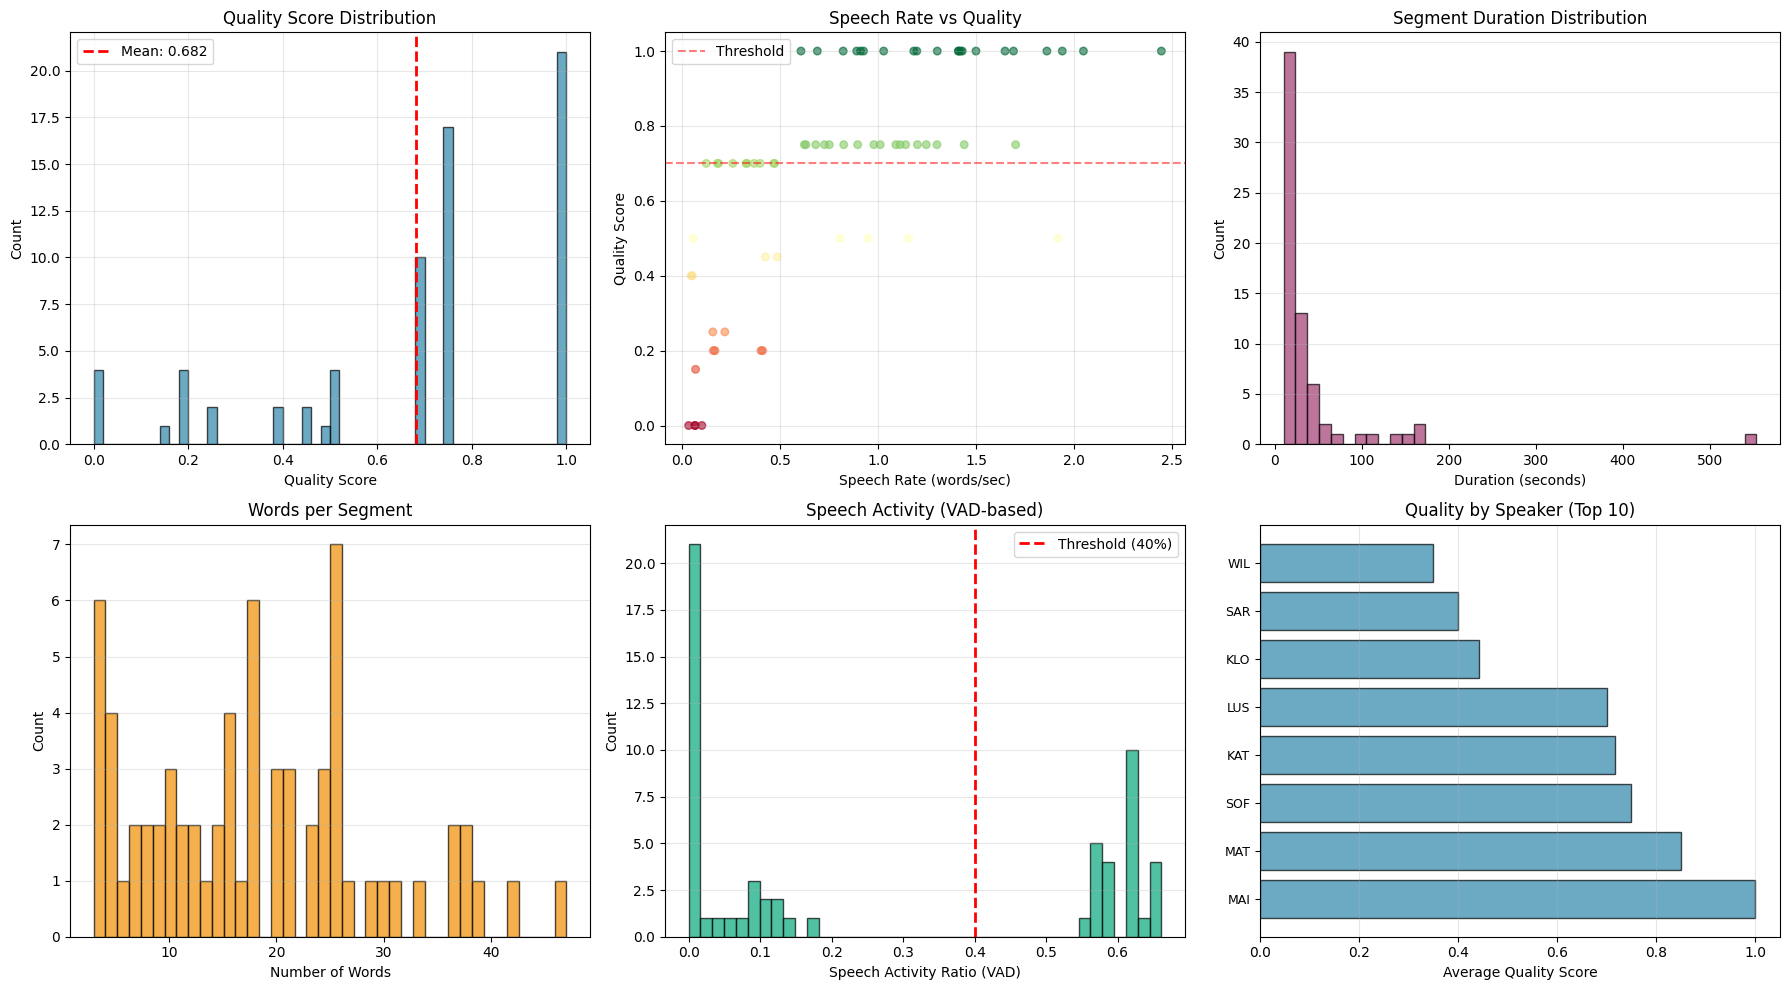

 ZONE 7 COMPLETE

   Input segments (from Zone 6):  68
   Output segments (quality filtered): 48


In [26]:
# ════════════════════════════════════════════════════════════════════════════
# ZONE 6: DATA QUALITY ANALYSIS (AVEC VAD MODEL LÉGER)
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path


# ════════════════════════════════════════════════════════════════════════════
# LIGHTWEIGHT VAD MODEL (Silence Detection)
# ════════════════════════════════════════════════════════════════════════════

class LightweightVAD:
    """
    Lightweight Voice Activity Detection model.
    Uses energy-based detection without neural networks.

    Fast, lightweight, no model dependencies needed.
    """

    def __init__(self,
                 sr: int = 16000,
                 frame_length: int = 512,
                 hop_length: int = 512,
                 energy_threshold_percentile: int = 30):
        """
        Initialize VAD model.

        Args:
            sr: Sample rate
            frame_length: FFT window size
            hop_length: Hop length for STFT
            energy_threshold_percentile: Percentile for threshold (0-100)
        """
        self.sr = sr
        self.frame_length = frame_length
        self.hop_length = hop_length
        self.energy_threshold_percentile = energy_threshold_percentile

    def detect(self, y: np.ndarray) -> tuple:
        """
        Detect speech activity in audio signal.

        Args:
            y: Audio waveform

        Returns:
            (speech_ratio, speech_frames, threshold)
            - speech_ratio: Proportion of frames with speech (0-1)
            - speech_frames: Boolean array indicating speech frames
            - threshold: Energy threshold used
        """

        # Compute RMS energy
        rms = librosa.feature.rms(y=y, frame_length=self.frame_length,
                                  hop_length=self.hop_length)[0]

        # Compute dynamic threshold based on percentile
        threshold = np.percentile(rms, self.energy_threshold_percentile)

        # Detect speech frames (above threshold)
        speech_frames = rms > threshold

        # Compute speech activity ratio
        speech_ratio = np.sum(speech_frames) / len(speech_frames) if len(speech_frames) > 0 else 0

        return speech_ratio, speech_frames, threshold


class EnhancedVAD(LightweightVAD):
    """
    Enhanced VAD with additional acoustic features.

    Combines:
    - Energy-based detection
    - Zero-crossing rate
    - Spectral flatness
    """

    def __init__(self, sr: int = 16000, frame_length: int = 512, hop_length: int = 512):
        super().__init__(sr, frame_length, hop_length)

    def detect_enhanced(self, y: np.ndarray) -> dict:
        """
        Enhanced speech detection using multiple features.

        Args:
            y: Audio waveform

        Returns:
            Dictionary with:
            - speech_ratio: Main speech activity ratio
            - energy_speech_ratio: From energy alone
            - zcr_speech_ratio: From zero-crossing rate
            - spectral_speech_ratio: From spectral flatness
            - combined_speech_ratio: Consensus decision
            - details: Dict with detailed metrics
        """

        # Feature 1: RMS Energy
        rms = librosa.feature.rms(y=y, frame_length=self.frame_length,
                                  hop_length=self.hop_length)[0]
        energy_threshold = np.percentile(rms, 30)
        energy_speech = rms > energy_threshold
        energy_ratio = np.sum(energy_speech) / len(energy_speech)

        # Feature 2: Zero-Crossing Rate (high ZCR = unvoiced/noise)
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=self.hop_length)[0]
        zcr_threshold = np.percentile(zcr, 60)  # High ZCR threshold
        zcr_speech = zcr < zcr_threshold
        zcr_ratio = np.sum(zcr_speech) / len(zcr_speech)

        # Feature 3: Spectral Flatness (low flatness = tonal speech)
        S = librosa.stft(y)
        freqs = librosa.fft_frequencies(sr=self.sr)

        # Simple spectral flatness: ratio of geometric to arithmetic mean
        magnitude = np.abs(S)
        spectral_flatness = np.zeros(magnitude.shape[1])

        for t in range(magnitude.shape[1]):
            spectrum = magnitude[:, t]
            if np.sum(spectrum) > 0:
                geom_mean = np.exp(np.mean(np.log(spectrum + 1e-10)))
                arith_mean = np.mean(spectrum)
                spectral_flatness[t] = geom_mean / (arith_mean + 1e-10)

        spectral_threshold = np.percentile(spectral_flatness, 40)
        spectral_speech = spectral_flatness < spectral_threshold
        spectral_ratio = np.sum(spectral_speech) / len(spectral_flatness)

        # Consensus: frames that agree on at least 2 features
        consensus = (energy_speech.astype(int) +
                    zcr_speech.astype(int) +
                    spectral_speech.astype(int)) >= 2
        combined_ratio = np.sum(consensus) / len(consensus)

        return {
            'speech_ratio': combined_ratio,  # Main metric
            'energy_speech_ratio': energy_ratio,
            'zcr_speech_ratio': zcr_ratio,
            'spectral_speech_ratio': spectral_ratio,
            'combined_speech_ratio': combined_ratio,
            'details': {
                'energy_threshold': energy_threshold,
                'zcr_threshold': zcr_threshold,
                'spectral_threshold': spectral_threshold,
                'energy_speech_frames': np.sum(energy_speech),
                'zcr_speech_frames': np.sum(zcr_speech),
                'spectral_speech_frames': np.sum(spectral_speech),
                'consensus_frames': np.sum(consensus),
                'total_frames': len(energy_speech)
            }
        }


# ════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION WITH VAD
# ════════════════════════════════════════════════════════════════════════════

def extract_audio_segment_features_with_vad(audio_segments, use_enhanced_vad=True):
    """
    Extract features from audio segments using VAD model for accurate speech ratio.

    Args:
        audio_segments: List of MergedSegment objects from Zone 6
        use_enhanced_vad: Use enhanced VAD (True) or basic VAD (False)

    Returns:
        DataFrame with extracted features including VAD-based speech_activity_ratio
    """

    rows = []

    print(f"\n{'='*80}")
    print("ZONE 6: EXTRACTING FEATURES WITH VAD")
    print(f"{'='*80}\n")

    # Initialize VAD model
    if use_enhanced_vad:
        print("Using Enhanced VAD (multi-feature)\n")
        vad = EnhancedVAD(sr=16000)
    else:
        print("Using Lightweight VAD (energy-based)\n")
        vad = LightweightVAD(sr=16000)

    for i, seg in enumerate(tqdm(audio_segments, desc="Processing segments")):
        # Access attributes directly from MergedSegment object
        audio_path = Path(seg.merged_audio_path)

        features = {
            'segment_id': seg.merge_id,
            'speaker': seg.speaker,
            'duration_ms': seg.merged_duration_ms,
            'text': seg.merged_text,
            'n_words': seg.num_words,
            'text_length': len(seg.merged_text),
        }

        # Speech rate
        if seg.merged_duration_ms > 0:
            features['speech_rate_wps'] = seg.num_words / (seg.merged_duration_ms / 1000)
        else:
            features['speech_rate_wps'] = 0

        # Load and analyze audio with VAD
        if audio_path.exists():
            try:
                y, sr = librosa.load(str(audio_path), sr=16000)

                # ✅ VAD-based speech activity (IMPROVED)
                if use_enhanced_vad:
                    vad_result = vad.detect_enhanced(y)
                    features['speech_activity_ratio'] = vad_result['speech_ratio']
                    features['vad_energy_ratio'] = vad_result['energy_speech_ratio']
                    features['vad_zcr_ratio'] = vad_result['zcr_speech_ratio']
                    features['vad_spectral_ratio'] = vad_result['spectral_speech_ratio']
                else:
                    speech_ratio, _, _ = vad.detect(y)
                    features['speech_activity_ratio'] = speech_ratio

                # RMS Energy
                rms = librosa.feature.rms(y=y)[0]
                features['energy_mean'] = np.mean(rms)
                features['energy_std'] = np.std(rms)

                # Zero-crossing rate
                zcr = librosa.feature.zero_crossing_rate(y)[0]
                features['zcr_mean'] = np.mean(zcr)

                # Dynamic range
                db = librosa.power_to_db(np.abs(librosa.stft(y))**2, ref=np.max)
                features['dynamic_range'] = np.max(db) - np.min(db)

                # Spectral centroid
                spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
                features['spectral_centroid'] = np.mean(spectral_centroids)

            except Exception as e:
                print(f"  ⚠️  Error processing {audio_path}: {e}")
                features.update({
                    'speech_activity_ratio': np.nan,
                    'energy_mean': np.nan,
                    'energy_std': np.nan,
                    'zcr_mean': np.nan,
                    'dynamic_range': np.nan,
                    'spectral_centroid': np.nan,
                })
        else:
            features.update({
                'speech_activity_ratio': np.nan,
                'energy_mean': np.nan,
                'energy_std': np.nan,
                'zcr_mean': np.nan,
                'dynamic_range': np.nan,
                'spectral_centroid': np.nan,
            })

        rows.append(features)

    df = pd.DataFrame(rows)
    print(f"\n✅ Extracted features for {len(df)} segments\n")
    return df


# ════════════════════════════════════════════════════════════════════════════
# QUALITY SCORING
# ════════════════════════════════════════════════════════════════════════════

class AudioQualityScorer:
    """
    Score audio segment quality based on acoustic and metadata features.
    Uses VAD-based speech activity detection.
    """

    def __init__(self):
        self.rules = {
            'speech_rate': {
                'min': 0.5,
                'max': 6,
                'penalty': 0.3,
                'reason': 'Speech rate outside normal range (0.5-6 words/sec)'
            },
            'duration': {
                'min_ms': 5000,
                'max_ms': 60000,
                'penalty': 0.2,
                'reason': 'Segment duration outside range (5-60 sec)'
            },
            'text_length': {
                'min_chars': 10,
                'penalty': 0.1,
                'reason': 'Text too short (< 10 characters)'
            },
            'speech_activity': {
                'min_ratio': 0.4,  # VAD should detect at least 40% speech
                'penalty': 0.25,
                'reason': 'Too much silence/noise (<40% speech activity by VAD)'
            },
            'energy': {
                'min_mean': 0.01,
                'penalty': 0.1,
                'reason': 'Audio too quiet'
            },
            'dynamic_range': {
                'min_db': 5.0,
                'penalty': 0.15,
                'reason': 'Poor dynamic range'
            }
        }

    def score(self, df):
        """Compute quality scores for each segment."""
        if df.empty:
            return np.array([]), {}

        scores = np.ones(len(df))
        issues = {i: [] for i in range(len(df))}

        # Rule 1: Speech rate
        bad = (df['speech_rate_wps'] < self.rules['speech_rate']['min']) | \
              (df['speech_rate_wps'] > self.rules['speech_rate']['max'])
        scores[bad] -= self.rules['speech_rate']['penalty']
        for idx in df[bad].index:
            issues[idx].append(self.rules['speech_rate']['reason'])

        # Rule 2: Duration
        bad = (df['duration_ms'] < self.rules['duration']['min_ms']) | \
              (df['duration_ms'] > self.rules['duration']['max_ms'])
        scores[bad] -= self.rules['duration']['penalty']
        for idx in df[bad].index:
            issues[idx].append(self.rules['duration']['reason'])

        # Rule 3: Text length
        bad = df['text_length'] < self.rules['text_length']['min_chars']
        scores[bad] -= self.rules['text_length']['penalty']
        for idx in df[bad].index:
            issues[idx].append(self.rules['text_length']['reason'])

        # Rule 4: Speech activity (VAD-based) - IMPROVED
        if 'speech_activity_ratio' in df.columns:
            bad = (df['speech_activity_ratio'] < self.rules['speech_activity']['min_ratio']) & \
                  (df['speech_activity_ratio'].notna())
            scores[bad] -= self.rules['speech_activity']['penalty']
            for idx in df[bad].index:
                issues[idx].append(self.rules['speech_activity']['reason'])

        # Rule 5: Energy
        if 'energy_mean' in df.columns:
            bad = (df['energy_mean'] < self.rules['energy']['min_mean']) & \
                  (df['energy_mean'].notna())
            scores[bad] -= self.rules['energy']['penalty']
            for idx in df[bad].index:
                issues[idx].append(self.rules['energy']['reason'])

        # Rule 6: Dynamic range
        if 'dynamic_range' in df.columns:
            bad = (df['dynamic_range'] < self.rules['dynamic_range']['min_db']) & \
                  (df['dynamic_range'].notna())
            scores[bad] -= self.rules['dynamic_range']['penalty']
            for idx in df[bad].index:
                issues[idx].append(self.rules['dynamic_range']['reason'])

        return np.clip(scores, 0, 1), issues


def compute_quality_scores(df):
    """Compute quality scores using AudioQualityScorer."""
    if df.empty:
        print("No features to score, returning empty DataFrame.")
        # Ensure columns are present for subsequent operations, even if empty
        return pd.DataFrame(columns=df.columns.tolist() + ['quality_score', 'quality_issues'])

    scorer = AudioQualityScorer()
    scores, issues = scorer.score(df)
    df['quality_score'] = scores
    # Convert issues dictionary to a list matching DataFrame index
    df['quality_issues'] = [issues.get(idx, []) for idx in df.index]
    return df


# ════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

def plot_quality_analysis(df):
    """Plot comprehensive quality analysis."""
    if df.empty:
        print("No data to plot for quality analysis.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Quality score distribution
    axes[0, 0].hist(df['quality_score'], bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['quality_score'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df["quality_score"].mean():.3f}')
    axes[0, 0].set_xlabel('Quality Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Quality Score Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Speech rate vs quality
    axes[0, 1].scatter(df['speech_rate_wps'], df['quality_score'],
                      c=df['quality_score'], cmap='RdYlGn', alpha=0.6, s=30)
    axes[0, 1].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Threshold')
    axes[0, 1].set_xlabel('Speech Rate (words/sec)')
    axes[0, 1].set_ylabel('Quality Score')
    axes[0, 1].set_title('Speech Rate vs Quality')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Duration distribution
    axes[0, 2].hist(df['duration_ms']/1000, bins=40, color='#A23B72', alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('Duration (seconds)')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].set_title('Segment Duration Distribution')
    axes[0, 2].grid(True, alpha=0.3, axis='y')

    # 4. Word count distribution
    axes[1, 0].hist(df['n_words'], bins=40, color='#F18F01', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Number of Words')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Words per Segment')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 5. Speech activity (VAD) - NOW WITH VAD MODEL
    if 'speech_activity_ratio' in df.columns:
        axes[1, 1].hist(df['speech_activity_ratio'].dropna(), bins=40, color='#06A77D',
                       alpha=0.7, edgecolor='black')
        axes[1, 1].axvline(0.4, color='red', linestyle='--', linewidth=2, label='Threshold (40%)')
        axes[1, 1].set_xlabel('Speech Activity Ratio (VAD)')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].set_title('Speech Activity (VAD-based)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, axis='y')

    # 6. Quality by speaker
    if 'speaker' in df.columns:
        speaker_quality = df.groupby('speaker')['quality_score'].mean().sort_values(ascending=False).head(10)
        axes[1, 2].barh(range(len(speaker_quality)), speaker_quality.values,
                       color='#2E86AB', alpha=0.7, edgecolor='black')
        axes[1, 2].set_yticks(range(len(speaker_quality)))
        axes[1, 2].set_yticklabels(speaker_quality.index, fontsize=9)
        axes[1, 2].set_xlabel('Average Quality Score')
        axes[1, 2].set_title('Quality by Speaker (Top 10)')
        axes[1, 2].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    return fig


# ════════════════════════════════════════════════════════════════════════════
# QUALITY REPORT AND FILTERING
# ════════════════════════════════════════════════════════════════════════════

def filter_and_report_quality(df, threshold=0.7):
    """Filter segments by quality and print detailed report."""

    print(f"\n{'='*80}")
    print("ZONE 7: DATA QUALITY ANALYSIS & FILTERING")
    print(f"{'='*80}\n")

    if df.empty:
        print("No segments to analyze or filter, returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    print(f"📊 OVERALL STATISTICS")
    print(f"   Total segments analyzed: {len(df):,}")
    print(f"   Quality score range: [{df['quality_score'].min():.3f}, {df['quality_score'].max():.3f}]")
    print(f"   Mean quality score: {df['quality_score'].mean():.3f}")
    print(f"   Median quality score: {df['quality_score'].median():.3f}\n")

    # Speech activity statistics (VAD)
    if 'speech_activity_ratio' in df.columns:
        print(f"🎙️  SPEECH ACTIVITY (VAD-based)")
        print(f"   Mean speech ratio: {df['speech_activity_ratio'].mean():.2%}")
        print(f"   Segments with <40% speech: {(df['speech_activity_ratio'] < 0.4).sum()} ({(df['speech_activity_ratio'] < 0.4).mean()*100:.1f}%)\n")

    # Filter
    high_quality = df[df['quality_score'] >= threshold].copy()
    removed = df[df['quality_score'] < threshold].copy()

    print(f"🎯 FILTERING RESULTS (threshold: {threshold})")
    print(f"   ✅ KEPT:    {len(high_quality):6d} ({len(high_quality)/len(df)*100:5.1f}%)  HIGH-QUALITY")
    print(f"   ❌ REMOVED: {len(removed):6d} ({len(removed)/len(df)*100:5.1f}%)  LOW-QUALITY\n")

    # Issue analysis
    if len(removed) > 0:
        print(f"📋 WHY SEGMENTS WERE REMOVED")
        issue_counts = {}
        for issues_list in removed['quality_issues']:
            for issue in issues_list:
                issue_counts[issue] = issue_counts.get(issue, 0) + 1

        for issue, count in sorted(issue_counts.items(), key=lambda x: -x[1]):
            pct = count / len(removed) * 100 if len(removed) > 0 else 0
            print(f"   • {issue:60s}: {count:5d} ({pct:5.1f}%)")

    # Stats on high-quality segments
    if len(high_quality) > 0:
        print(f"\n✅ HIGH-QUALITY SEGMENTS STATISTICS")
        print(f"   Avg duration: {high_quality['duration_ms'].mean()/1000:.2f}s")
        print(f"   Avg words: {high_quality['n_words'].mean():.1f}")
        print(f"   Avg speech rate: {high_quality['speech_rate_wps'].mean():.2f} words/sec")
        if 'speech_activity_ratio' in high_quality.columns:
            print(f"   Avg speech activity (VAD): {high_quality['speech_activity_ratio'].mean():.2%}")

    print(f"\n{'='*80}\n")

    return high_quality, removed


# ════════════════════════════════════════════════════════════════════════════
# MAIN ZONE 6 EXECUTION
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ZONE 7: DATA QUALITY ANALYSIS (WITH VAD)")
print("="*80)

# Extract features with VAD
features_df = extract_audio_segment_features_with_vad(
    audio_segments=merged_segments,  # From ZONE 7
    use_enhanced_vad=True  # Use enhanced VAD with multi-feature detection
)

# Compute quality scores
features_df = compute_quality_scores(features_df)

# Filter and report
quality_segments, removed_segments = filter_and_report_quality(
    features_df,
    threshold=0.7  # Keep segments with quality score >= 0.7
)

# Visualize
if not features_df.empty:
    fig = plot_quality_analysis(features_df)
    plt.show()
else:
    print("No quality analysis plots generated as features_df is empty.")

print(f" ZONE 7 COMPLETE\n")
print(f"   Input segments (from Zone 6):  {len(merged_segments)}")
print(f"   Output segments (quality filtered): {len(quality_segments)}")

## Zone 8 : Whisper Baseline Evaluation Compute of the WER before fine-tuning

In [32]:
@dataclass
class TranscriptionResult:
    segment_id: str
    speaker: str
    file_name: str
    audio_path: str
    ground_truth: str
    whisper_prediction: str
    duration_ms: int
    wer: float
    confidence: float = 0.0


class WhisperEvaluator:
    """Evaluate Whisper baseline on children voices"""

    def __init__(self, model_name: str = "base"):
        print(f"Loading Whisper '{model_name}'...")
        self.model = whisper.load_model(model_name)
        print("Loaded\n")

    def transcribe(self, audio_path: Path) -> Dict:
        if not audio_path.exists():
            return {"text": "", "confidence": 0.0}
        try:
            result = self.model.transcribe(str(audio_path), language="fr", verbose=False)
            return {"text": result["text"].strip(), "confidence": result.get("confidence", 0.0)}
        except:
            return {"text": "", "confidence": 0.0}

    @staticmethod
    def calculate_wer(ground_truth: str, prediction: str) -> float:
        if not ground_truth.strip():
            return 0.0 if not prediction.strip() else 1.0
        return compute_wer(ground_truth, prediction)

    def evaluate_children(self, audio_segments: List[Dict], speakers_info: Dict,
                         sample_size: int = None) -> List[TranscriptionResult]:
        """Evaluate only children speakers"""

        print("="*70)
        print("STEP 4: WHISPER BASELINE EVALUATION (CHILDREN ONLY)")
        print("="*70)

        # Filter children only
        children_segments = [s for s in audio_segments
                            if speakers_info.get(s["speaker"]) in CHILD_ROLES]

        if sample_size:
            children_segments = children_segments[:sample_size]

        print(f"\nEvaluating {len(children_segments)} children segments\n")

        results = []
        for i, seg in enumerate(children_segments):
            audio_path = Path(seg["audio_path"])
            transcription = self.transcribe(audio_path)
            # Corrected: Access 'ground_truth' instead of 'text'
            wer = self.calculate_wer(seg["ground_truth"], transcription["text"])

            results.append(TranscriptionResult(
                segment_id=seg["segment_id"],
                speaker=seg["speaker"],
                file_name=seg["file_name"],
                audio_path=seg["audio_path"],
                ground_truth=seg["ground_truth"],
                whisper_prediction=transcription["text"],
                duration_ms=seg["duration_ms"],
                wer=wer,
                confidence=transcription["confidence"]
            ))

            if (i + 1) % 50 == 0:
                avg_wer = sum(r.wer for r in results) / len(results)
                print(f"  ✓ {i + 1}/{len(children_segments)} | Avg WER: {avg_wer:.3f}")

        return results

## Zone 9: WER Report

In [33]:
def print_wer_report(results: List[TranscriptionResult], speakers_info: Dict):
    """Print WER statistics"""

    wers = [r.wer for r in results]

    print("\n" + "="*70)
    print("STEP 5: WER STATISTICS (CHILDREN ONLY)")
    print("="*70)

    print(f"\nGlobal:")
    print(f"   Total segments:  {len(results)}")
    print(f"   Avg WER:         {sum(wers) / len(wers):.3f}")
    print(f"   Min WER:         {min(wers):.3f}")
    print(f"   Max WER:         {max(wers):.3f}")
    print(f"   Median WER:      {sorted(wers)[len(wers)//2]:.3f}")

    print(f"\n   Distribution:")
    for low, high in [(0.0, 0.1), (0.1, 0.3), (0.3, 0.5), (0.5, 1.0)]:
        count = sum(1 for w in wers if low <= w < high)
        pct = (count / len(wers)) * 100
        print(f"      {low:.1f}-{high:.1f}: {count:4d} ({pct:5.1f}%)")

    # By speaker
    by_speaker = {}
    for r in results:
        by_speaker.setdefault(r.speaker, []).append(r.wer)

    print(f"\n👥 By speaker ({len(by_speaker)}):")
    for speaker in sorted(by_speaker.keys()):
        wers_sp = by_speaker[speaker]
        avg = sum(wers_sp) / len(wers_sp)
        print(f"      {speaker:15} {len(wers_sp):4d} segments | WER: {avg:.3f}")

    print("\n" + "="*70 + "\n")


In [34]:
print("\n" + "="*70)
print("ZONE 6: WHISPER EVALUATION (HIGH-QUALITY SEGMENTS ONLY)")
print("="*70)

    # Filter audio_segments to only include high-quality ones
high_quality_ids = set(quality_segments['speaker'].unique())
filtered_audio_segments = [
    seg for seg in merged_segments # Changed from audio_segments to merged_segments
    if seg.speaker in high_quality_ids  # Use seg.speaker for MergedSegment object
]

# Adjusting the structure for segments used in WhisperEvaluator.
# The original `audio_segments` list contained dicts, but after merging, we have `MergedSegment` objects.
# The WhisperEvaluator expects a list of dictionaries with specific keys. So, convert MergedSegment objects to dicts.
whisper_input_segments = []
for seg_obj in filtered_audio_segments:
    # Create a dictionary structure that WhisperEvaluator expects
    whisper_input_segments.append({
        "segment_id": seg_obj.merge_id,
        "speaker": seg_obj.speaker,
        "file_name": seg_obj.file_name,
        "audio_path": str(seg_obj.merged_audio_path), # Convert Path to string
        "ground_truth": seg_obj.merged_text,
        "duration_ms": seg_obj.merged_duration_ms
    })

print(f"\n   📊 Using {len(whisper_input_segments)}/{len(merged_segments)} segments for Whisper")
print(f"      (Filtered: {len(merged_segments) - len(whisper_input_segments)} low-quality segments removed)")

evaluator = WhisperEvaluator(CONFIG["whisper_model"])
results = evaluator.evaluate_children(
    whisper_input_segments,  # HIGH-QUALITY ONLY!
    speakers_info,
    CONFIG["sample_size"]
)

print_wer_report(results, speakers_info)



ZONE 6: WHISPER EVALUATION (HIGH-QUALITY SEGMENTS ONLY)

   📊 Using 67/68 segments for Whisper
      (Filtered: 1 low-quality segments removed)
Loading Whisper 'base'...
Loaded

STEP 4: WHISPER BASELINE EVALUATION (CHILDREN ONLY)

Evaluating 13 children segments



100%|██████████| 1321/1321 [00:06<00:00, 196.77frames/s]
0frames [00:00, ?frames/s]
  0%|          | 0/16045 [00:00<?, ?frames/s]
0frames [00:00, ?frames/s]
  0%|          | 0/4930 [00:00<?, ?frames/s]
0frames [00:00, ?frames/s]
0frames [00:00, ?frames/s]
0frames [00:00, ?frames/s]
100%|██████████| 1093/1093 [00:02<00:00, 536.67frames/s]


STEP 5: WER STATISTICS (CHILDREN ONLY)

Global:
   Total segments:  13
   Avg WER:         1.609
   Min WER:         1.000
   Max WER:         5.667
   Median WER:      1.000

   Distribution:
      0.0-0.1:    0 (  0.0%)
      0.1-0.3:    0 (  0.0%)
      0.3-0.5:    0 (  0.0%)
      0.5-1.0:    0 (  0.0%)

👥 By speaker (5):
      KLO                7 segments | WER: 1.667
      LUS                1 segments | WER: 4.250
      MAI                1 segments | WER: 1.000
      MAT                2 segments | WER: 1.000
      WIL                2 segments | WER: 1.000




## Zone 10: Create Training Dataset

In [35]:
# When i am done i have to analyze the datas before creation of the training set


class DatasetBuilder:
    """Create train/test splits for fine-tuning"""

    def __init__(self, output_dir: Path):
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def create_dataset(self, results: List[TranscriptionResult], train_ratio: float = 0.8):
        """Create JSONL + metadata files"""

        print("="*70)
        print("STEP 6: CREATE TRAINING DATASET")
        print("="*70)

        split_idx = int(len(results) * train_ratio)
        train = results[:split_idx]
        test = results[split_idx:]

        print(f"\nDataset split:")
        print(f"   Total:   {len(results)} segments")
        print(f"   Train:   {len(train)} segments ({train_ratio*100:.0f}%)")
        print(f"   Test:    {len(test)} segments ({(1-train_ratio)*100:.0f}%)")

        # Save JSONL (for fine-tuning)
        self._save_jsonl(train, self.output_dir / "train.jsonl")
        self._save_jsonl(test, self.output_dir / "eval.jsonl")

        # Save metadata JSON (for analysis)
        self._save_metadata(train, self.output_dir / "train_metadata.json")
        self._save_metadata(test, self.output_dir / "eval_metadata.json")

        print(f"\nDataset created in {self.output_dir}\n")

    def _save_jsonl(self, results: List[TranscriptionResult], output_file: Path):
        """Save as JSONL for Whisper"""
        with open(output_file, "w", encoding="utf-8") as f:
            for r in results:
                entry = {"audio": r.audio_path, "text": r.ground_truth, "language": "fr"}
                f.write(json.dumps(entry, ensure_ascii=False) + "\n")
        print(f"   ✓ {output_file.name} ({len(results)} segments)")

    def _save_metadata(self, results: List[TranscriptionResult], output_file: Path):
        """Save complete metadata"""
        data = [asdict(r) for r in results]
        with open(output_file, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        print(f"   ✓ {output_file.name}")

In [36]:

    # ════════════════════════════════════════════════════════════════════════
    # ZONE 7: Create Training Dataset
    # ════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("ZONE 7: CREATE TRAINING DATASET")
print("="*70)

builder = DatasetBuilder(CONFIG["output_dir"] / "training_dataset")
builder.create_dataset(results, CONFIG["train_ratio"])



ZONE 7: CREATE TRAINING DATASET
STEP 6: CREATE TRAINING DATASET

Dataset split:
   Total:   13 segments
   Train:   10 segments (80%)
   Test:    3 segments (20%)
   ✓ train.jsonl (10 segments)
   ✓ eval.jsonl (3 segments)
   ✓ train_metadata.json
   ✓ eval_metadata.json

Dataset created in /content/drive/MyDrive/asr/output/whisper_children_dataset/training_dataset

